# Gradient Descent Explained 
### The Optimization Algorithm That Powers ML

**Gradient Descent = How machines learn**
- Find minimum of loss function
- Update parameters iteratively
- Follow the negative gradient
- Core of neural network training

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("bright")
np.random.seed(42)

## 1. The Problem: Finding the Minimum
**Goal: Minimize the loss function**

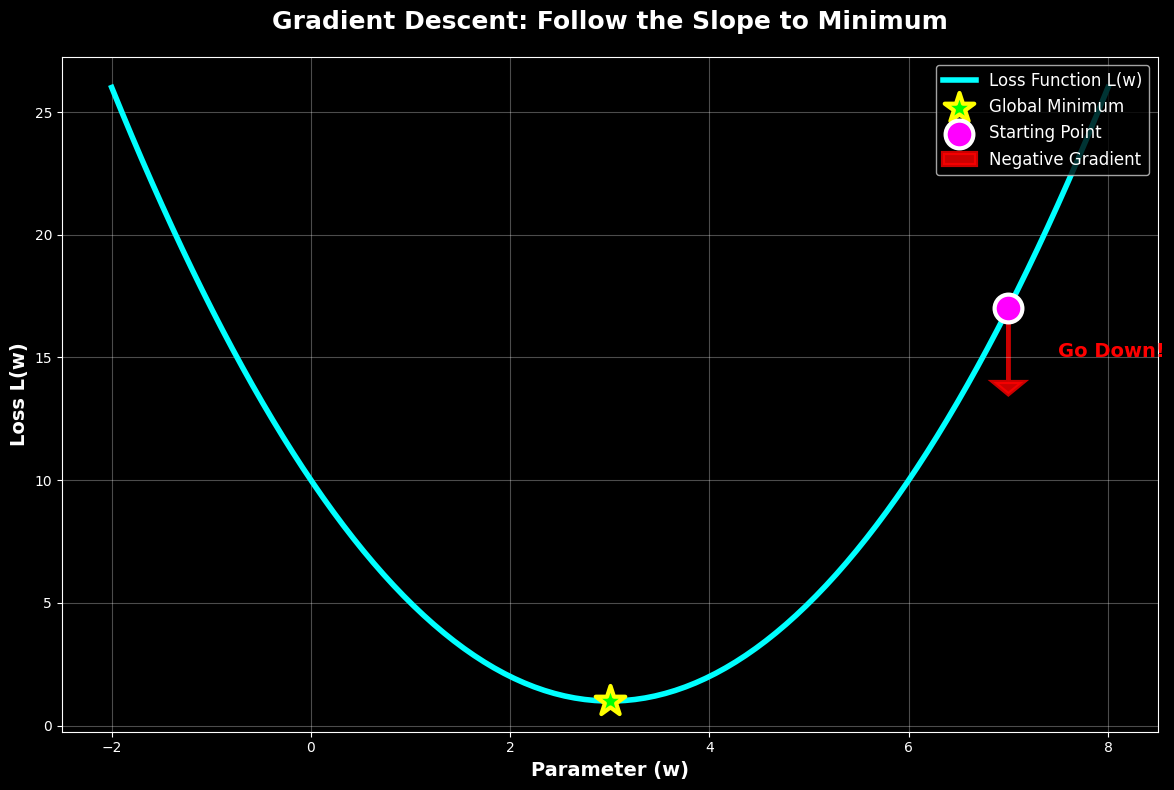

Starting at w = 7
Loss = 17.00
Gradient = 8.00 (positive = go left!)

Goal: Reach w = 3, Loss = 1.00


In [2]:
# Simple quadratic loss function: L(w) = (w - 3)² + 1
def loss_function(w):
    return (w - 3)**2 + 1

# Derivative (gradient): dL/dw = 2(w - 3)
def gradient(w):
    return 2 * (w - 3)

# Plot the loss function
w_values = np.linspace(-2, 8, 100)
loss_values = loss_function(w_values)

plt.figure(figsize=(12, 8))
plt.plot(w_values, loss_values, 'cyan', linewidth=4, label='Loss Function L(w)')

# Mark the minimum
min_w = 3
min_loss = loss_function(min_w)
plt.scatter(min_w, min_loss, s=500, c='lime', marker='*', 
           edgecolors='yellow', linewidth=3, zorder=5, label='Global Minimum')

# Mark a starting point
start_w = 7
start_loss = loss_function(start_w)
plt.scatter(start_w, start_loss, s=400, c='magenta', 
           edgecolors='white', linewidth=3, zorder=5, label='Starting Point')

# Draw gradient arrow at starting point
grad = gradient(start_w)
plt.arrow(start_w, start_loss, 0, -3, head_width=0.3, head_length=0.5,
         fc='red', ec='red', linewidth=3, alpha=0.8, label='Negative Gradient')
plt.text(start_w + 0.5, start_loss - 2, 'Go Down!', fontsize=14, 
        color='red', fontweight='bold')

plt.xlabel('Parameter (w)', fontsize=14, fontweight='bold')
plt.ylabel('Loss L(w)', fontsize=14, fontweight='bold')
plt.title('Gradient Descent: Follow the Slope to Minimum', 
         fontsize=18, fontweight='bold', pad=20)
plt.legend(fontsize=12, loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Starting at w = {start_w}")
print(f"Loss = {start_loss:.2f}")
print(f"Gradient = {grad:.2f} (positive = go left!)")
print(f"\nGoal: Reach w = {min_w}, Loss = {min_loss:.2f}")

## 2. The Algorithm: Gradient Descent
**Update rule: w_new = w_old - learning_rate × gradient**

In [3]:
# Gradient Descent Implementation
def gradient_descent(start_w, learning_rate, num_iterations):
    """
    Perform gradient descent optimization
    
    Parameters:
    - start_w: Initial parameter value
    - learning_rate: Step size (α)
    - num_iterations: Number of steps
    
    Returns:
    - history: List of (w, loss) tuples
    """
    w = start_w
    history = [(w, loss_function(w))]
    
    for i in range(num_iterations):
        # Compute gradient
        grad = gradient(w)
        
        # Update parameter
        w = w - learning_rate * grad
        
        # Store history
        history.append((w, loss_function(w)))
    
    return history

# Run gradient descent
start_w = 7.0
learning_rate = 0.1
num_iterations = 15

history = gradient_descent(start_w, learning_rate, num_iterations)

print("Gradient Descent Progress:")
print("="*50)
for i, (w, loss) in enumerate(history[:8]):  # Show first 8 steps
    print(f"Step {i}: w = {w:.4f}, Loss = {loss:.4f}")
if len(history) > 8:
    print("...")
    w, loss = history[-1]
    print(f"Step {len(history)-1}: w = {w:.4f}, Loss = {loss:.4f}")

print("\n" + "="*50)
print(f"Converged to w ≈ {history[-1][0]:.4f}")
print(f"True minimum at w = 3.0000")
print(f"Error: {abs(history[-1][0] - 3):.6f}")

Gradient Descent Progress:
Step 0: w = 7.0000, Loss = 17.0000
Step 1: w = 6.2000, Loss = 11.2400
Step 2: w = 5.5600, Loss = 7.5536
Step 3: w = 5.0480, Loss = 5.1943
Step 4: w = 4.6384, Loss = 3.6844
Step 5: w = 4.3107, Loss = 2.7180
Step 6: w = 4.0486, Loss = 2.0995
Step 7: w = 3.8389, Loss = 1.7037
...
Step 15: w = 3.1407, Loss = 1.0198

Converged to w ≈ 3.1407
True minimum at w = 3.0000
Error: 0.140737


## 3. Visualize the Descent
**Watch the algorithm find the minimum!**

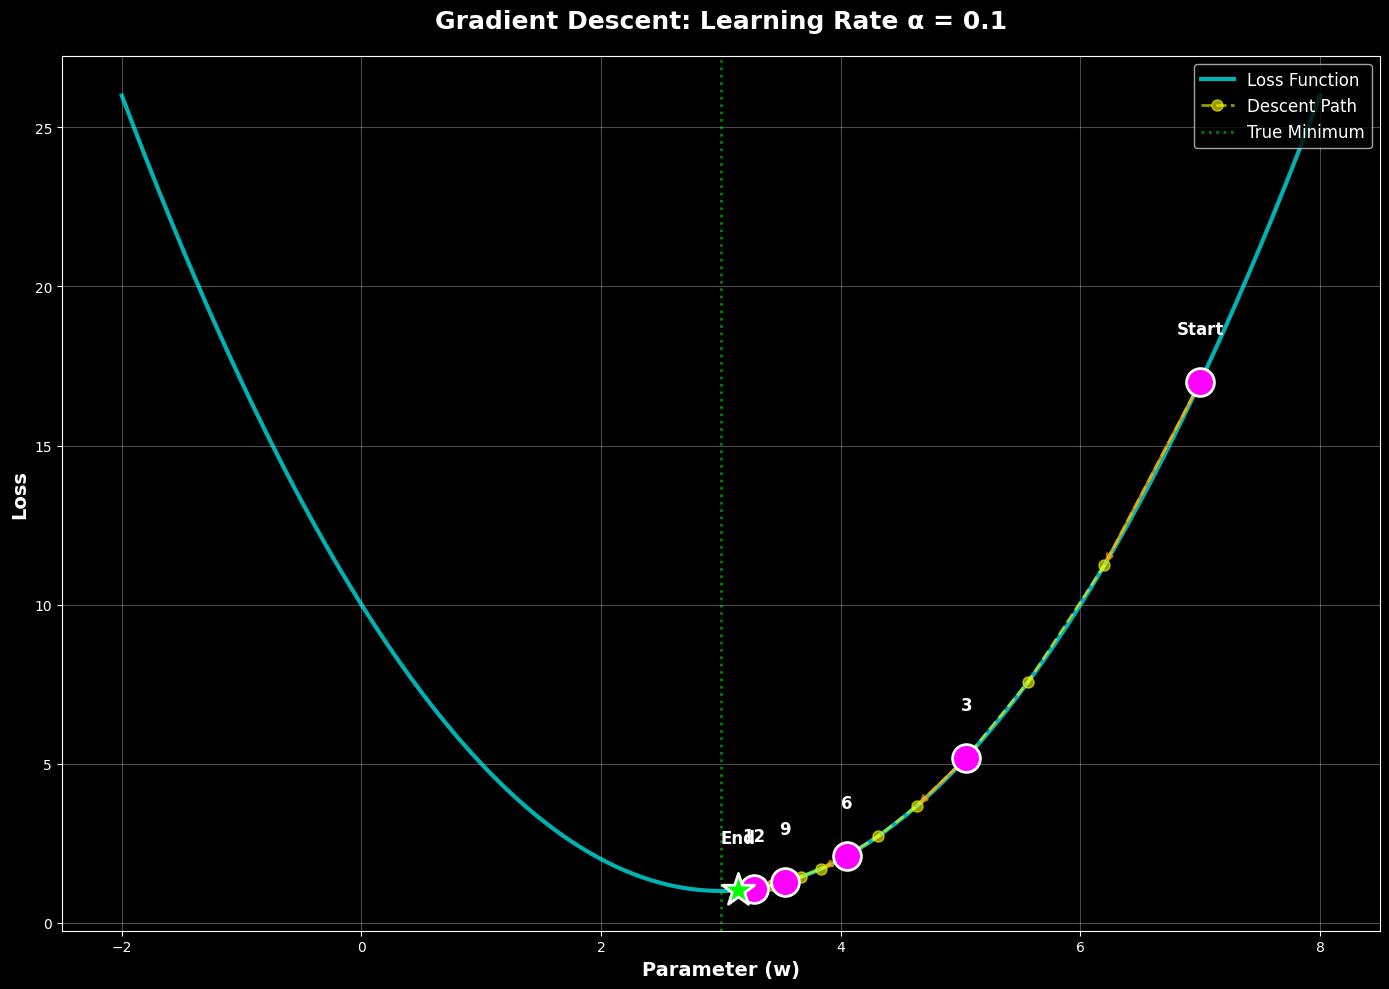

In [4]:
# Visualize gradient descent steps
fig, ax = plt.subplots(figsize=(14, 10))

# Plot loss function
w_range = np.linspace(-2, 8, 200)
loss_range = loss_function(w_range)
ax.plot(w_range, loss_range, 'cyan', linewidth=3, alpha=0.7, label='Loss Function')

# Plot gradient descent path
w_path = [h[0] for h in history]
loss_path = [h[1] for h in history]

# Draw path
ax.plot(w_path, loss_path, 'yellow', linewidth=2, linestyle='--', 
       alpha=0.6, marker='o', markersize=8, label='Descent Path')

# Annotate steps
for i, (w, loss) in enumerate(history):
    if i % 3 == 0 or i == len(history) - 1:  # Show every 3rd step
        color = 'lime' if i == len(history) - 1 else 'magenta'
        size = 600 if i == len(history) - 1 else 400
        marker = '*' if i == len(history) - 1 else 'o'
        
        ax.scatter(w, loss, s=size, c=color, marker=marker,
                  edgecolors='white', linewidth=2, zorder=5)
        
        if i < len(history) - 1:
            # Draw arrow to next step
            next_w, next_loss = history[i + 1]
            ax.annotate('', xy=(next_w, next_loss), xytext=(w, loss),
                       arrowprops=dict(arrowstyle='->', color='orange', 
                                     lw=2, alpha=0.7))
        
        # Label
        if i == 0:
            label = 'Start'
        elif i == len(history) - 1:
            label = 'End'
        else:
            label = f'{i}'
        
        ax.text(w, loss + 1.5, label, fontsize=12, ha='center',
               fontweight='bold', color='white')

# Mark true minimum
ax.axvline(x=3, color='lime', linestyle=':', linewidth=2, alpha=0.5, label='True Minimum')

ax.set_xlabel('Parameter (w)', fontsize=14, fontweight='bold')
ax.set_ylabel('Loss', fontsize=14, fontweight='bold')
ax.set_title(f'Gradient Descent: Learning Rate α = {learning_rate}', 
            fontsize=18, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Learning Rate Matters!
**Too small = slow, Too large = unstable**

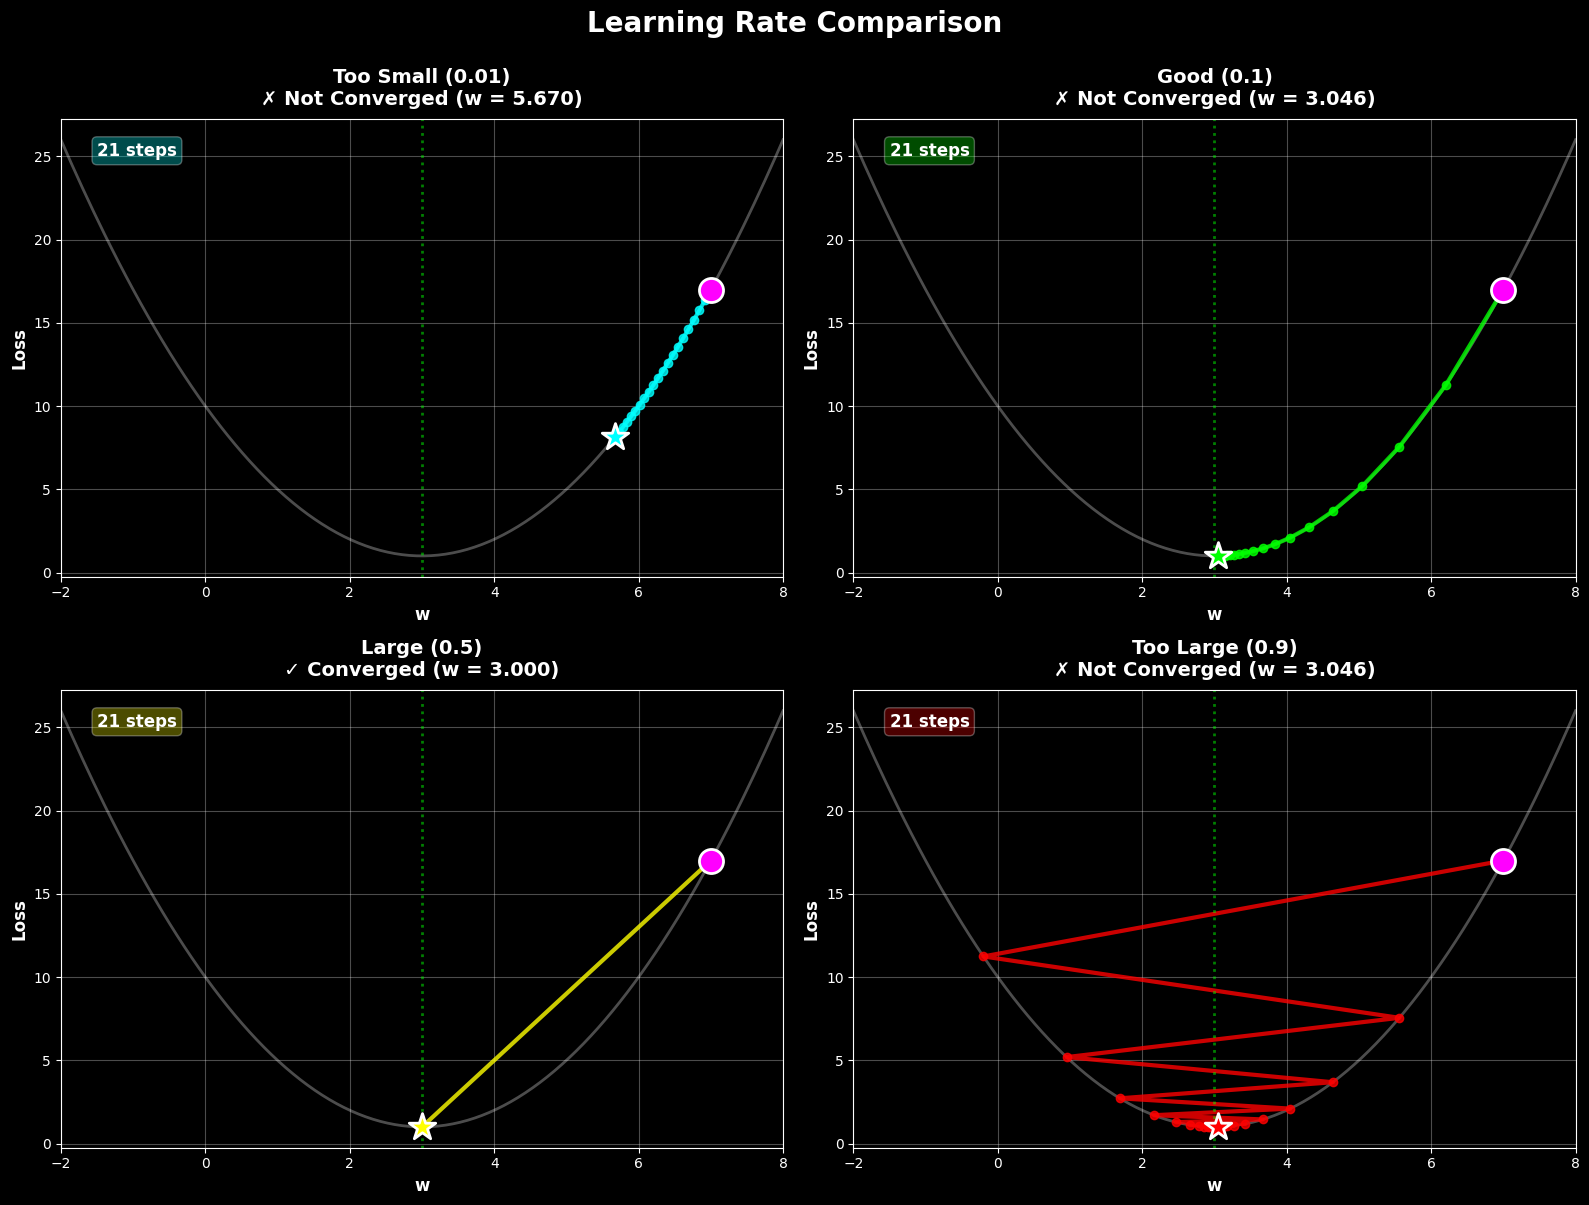

Learning Rate Effects:
α = 0.01: Too small → Slow convergence (many steps)
α = 0.10: Good → Fast & stable convergence
α = 0.50: Large → Faster but overshoots
α = 0.90: Too large → Oscillates, may diverge!

💡 Choosing right learning rate is CRITICAL!


In [5]:
# Compare different learning rates
learning_rates = [0.01, 0.1, 0.5, 0.9]
colors = ['cyan', 'lime', 'yellow', 'red']
labels = ['Too Small (0.01)', 'Good (0.1)', 'Large (0.5)', 'Too Large (0.9)']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (lr, color, label) in enumerate(zip(learning_rates, colors, labels)):
    ax = axes[idx]
    
    # Run gradient descent
    history_lr = gradient_descent(start_w=7.0, learning_rate=lr, num_iterations=20)
    
    # Plot loss function
    ax.plot(w_range, loss_range, 'white', linewidth=2, alpha=0.3)
    
    # Plot descent path
    w_path = [h[0] for h in history_lr]
    loss_path = [h[1] for h in history_lr]
    
    ax.plot(w_path, loss_path, color=color, linewidth=3, 
           marker='o', markersize=6, label='Path', alpha=0.8)
    
    # Mark start and end
    ax.scatter(w_path[0], loss_path[0], s=300, c='magenta', 
              edgecolors='white', linewidth=2, zorder=5, marker='o')
    ax.scatter(w_path[-1], loss_path[-1], s=400, c=color, 
              marker='*', edgecolors='white', linewidth=2, zorder=5)
    
    # True minimum line
    ax.axvline(x=3, color='lime', linestyle=':', linewidth=2, alpha=0.5)
    
    # Title with convergence info
    final_w = w_path[-1]
    converged = abs(final_w - 3) < 0.01
    status = '✓ Converged' if converged else '✗ Not Converged'
    
    ax.set_title(f'{label}\n{status} (w = {final_w:.3f})', 
                fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('w', fontsize=12, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_xlim([-2, 8])
    
    # Add step count
    ax.text(0.05, 0.95, f'{len(history_lr)} steps', 
           transform=ax.transAxes, fontsize=12, fontweight='bold',
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor=color, alpha=0.3))

plt.suptitle('Learning Rate Comparison', fontsize=20, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Learning Rate Effects:")
print("="*50)
print("α = 0.01: Too small → Slow convergence (many steps)")
print("α = 0.10: Good → Fast & stable convergence")
print("α = 0.50: Large → Faster but overshoots")
print("α = 0.90: Too large → Oscillates, may diverge!")
print("\n💡 Choosing right learning rate is CRITICAL!")

## 5. Real ML Example: Linear Regression
**Training a model with gradient descent**

In [6]:
# Generate training data: y = 2x + 1 + noise
np.random.seed(42)
X_train = np.random.rand(50) * 10
y_train = 2 * X_train + 1 + np.random.randn(50) * 2

# Model: y_pred = w * x + b
# Loss: MSE = (1/n) * Σ(y_pred - y_true)²

def predict(X, w, b):
    return w * X + b

def compute_loss(X, y, w, b):
    predictions = predict(X, w, b)
    return np.mean((predictions - y) ** 2)

def compute_gradients(X, y, w, b):
    n = len(X)
    predictions = predict(X, w, b)
    error = predictions - y
    
    dw = (2/n) * np.sum(error * X)
    db = (2/n) * np.sum(error)
    
    return dw, db

# Initialize parameters randomly
w = 0.0
b = 0.0
learning_rate = 0.01
num_epochs = 100

# Track history
loss_history = []
w_history = []
b_history = []

# Training loop
for epoch in range(num_epochs):
    # Compute loss
    loss = compute_loss(X_train, y_train, w, b)
    loss_history.append(loss)
    w_history.append(w)
    b_history.append(b)
    
    # Compute gradients
    dw, db = compute_gradients(X_train, y_train, w, b)
    
    # Update parameters (gradient descent!)
    w = w - learning_rate * dw
    b = b - learning_rate * db
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}: Loss = {loss:.4f}, w = {w:.4f}, b = {b:.4f}")

print("\nFinal Model:")
print(f"  w = {w:.4f} (true: 2.0)")
print(f"  b = {b:.4f} (true: 1.0)")
print(f"  Final Loss = {loss_history[-1]:.4f}")

Epoch   0: Loss = 132.8199, w = 1.2039, b = 0.1983
Epoch  20: Loss = 3.4629, w = 2.0774, b = 0.4327
Epoch  40: Loss = 3.4281, w = 2.0643, b = 0.5147
Epoch  60: Loss = 3.4004, w = 2.0525, b = 0.5878
Epoch  80: Loss = 3.3784, w = 2.0421, b = 0.6530

Final Model:
  w = 2.0332 (true: 2.0)
  b = 0.7085 (true: 1.0)
  Final Loss = 3.3616


## 6. Visualize Training Progress

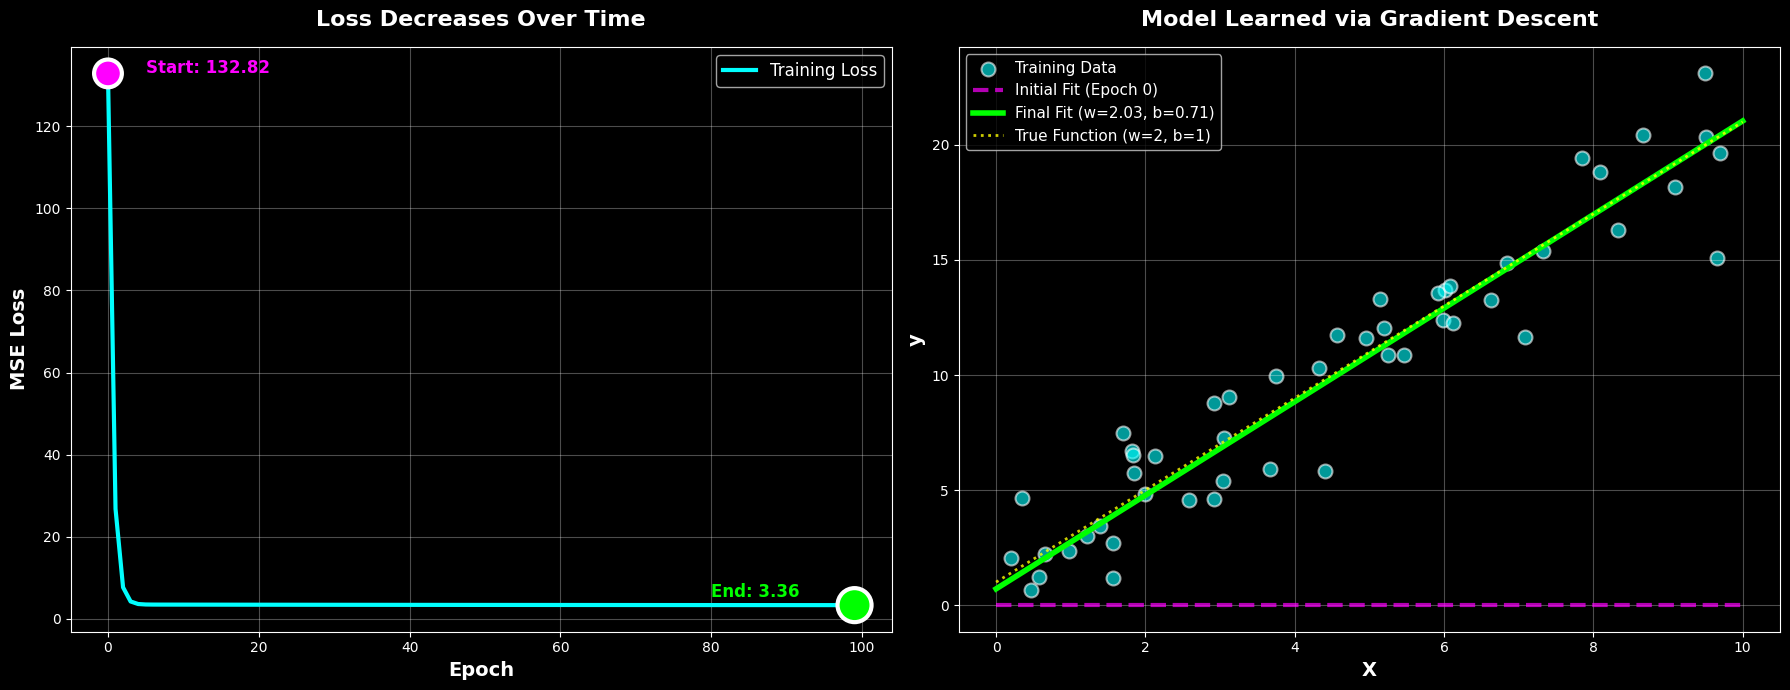


💡 Gradient Descent found optimal parameters!
   Loss decreased from 132.82 → 3.36
   Model converged to true function!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Loss curve
ax1 = axes[0]
ax1.plot(loss_history, 'cyan', linewidth=3, label='Training Loss')
ax1.scatter([0, len(loss_history)-1], 
           [loss_history[0], loss_history[-1]], 
           s=[400, 600], c=['magenta', 'lime'], 
           edgecolors='white', linewidth=3, zorder=5)
ax1.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax1.set_ylabel('MSE Loss', fontsize=14, fontweight='bold')
ax1.set_title('Loss Decreases Over Time', fontsize=16, fontweight='bold', pad=15)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=12)

# Add annotations
ax1.text(5, loss_history[0], f'Start: {loss_history[0]:.2f}', 
        fontsize=12, color='magenta', fontweight='bold')
ax1.text(len(loss_history)-20, loss_history[-1]+2, f'End: {loss_history[-1]:.2f}', 
        fontsize=12, color='lime', fontweight='bold')

# Plot 2: Final fit
ax2 = axes[1]

# Scatter plot of data
ax2.scatter(X_train, y_train, s=100, c='cyan', alpha=0.6, 
           edgecolors='white', linewidth=1.5, label='Training Data')

# Plot initial line (w=0, b=0)
x_line = np.linspace(0, 10, 100)
y_initial = predict(x_line, w_history[0], b_history[0])
ax2.plot(x_line, y_initial, 'magenta', linewidth=3, 
        linestyle='--', alpha=0.7, label='Initial Fit (Epoch 0)')

# Plot final line
y_final = predict(x_line, w, b)
ax2.plot(x_line, y_final, 'lime', linewidth=4, 
        label=f'Final Fit (w={w:.2f}, b={b:.2f})')

# Plot true line
y_true = 2 * x_line + 1
ax2.plot(x_line, y_true, 'yellow', linewidth=2, 
        linestyle=':', alpha=0.8, label='True Function (w=2, b=1)')

ax2.set_xlabel('X', fontsize=14, fontweight='bold')
ax2.set_ylabel('y', fontsize=14, fontweight='bold')
ax2.set_title('Model Learned via Gradient Descent', fontsize=16, fontweight='bold', pad=15)
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Gradient Descent found optimal parameters!")
print("   Loss decreased from {:.2f} → {:.2f}".format(loss_history[0], loss_history[-1]))
print("   Model converged to true function!")

## 7. 2D Gradient Descent Visualization
**Multiple parameters (w and b)**

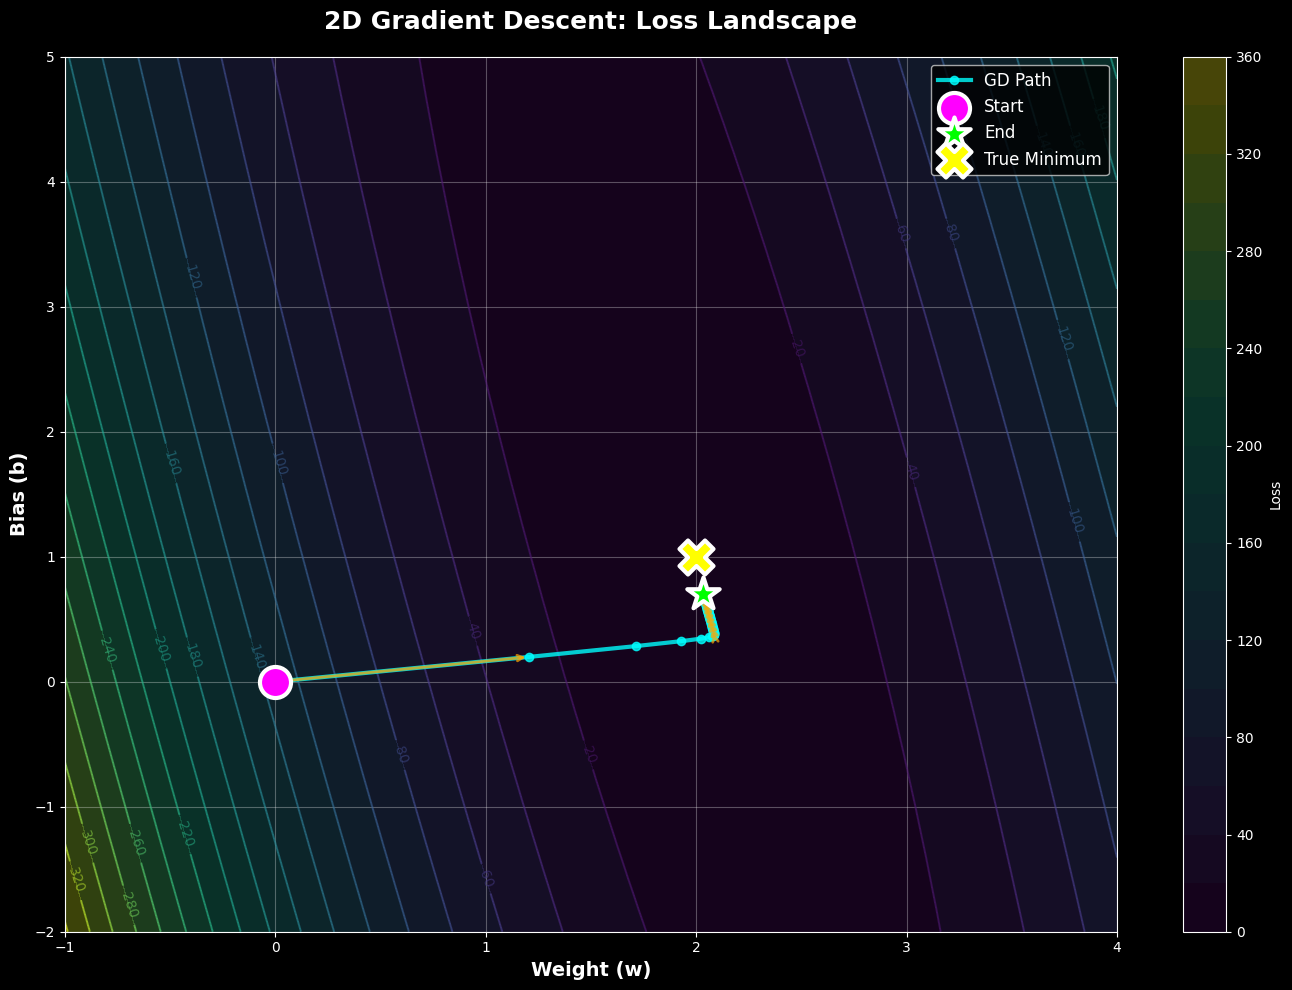


2D Gradient Descent:
  Started at: (w=0.00, b=0.00)
  Ended at:   (w=2.03, b=0.71)
  True min:   (w=2.00, b=1.00)

💡 Gradient descent navigates the loss landscape to find minimum!


In [8]:
# Create 2D loss landscape
w_grid = np.linspace(-1, 4, 100)
b_grid = np.linspace(-2, 5, 100)
W_mesh, B_mesh = np.meshgrid(w_grid, b_grid)

# Compute loss for each (w, b) pair
Loss_mesh = np.zeros_like(W_mesh)
for i in range(W_mesh.shape[0]):
    for j in range(W_mesh.shape[1]):
        Loss_mesh[i, j] = compute_loss(X_train, y_train, W_mesh[i, j], B_mesh[i, j])

# Create contour plot
fig, ax = plt.subplots(figsize=(14, 10))

# Plot contour
contour = ax.contour(W_mesh, B_mesh, Loss_mesh, levels=20, cmap='viridis', alpha=0.6)
ax.clabel(contour, inline=True, fontsize=10)

# Plot filled contour for better visualization
contourf = ax.contourf(W_mesh, B_mesh, Loss_mesh, levels=20, cmap='viridis', alpha=0.3)
plt.colorbar(contourf, ax=ax, label='Loss')

# Plot gradient descent path
ax.plot(w_history, b_history, 'cyan', linewidth=3, 
       marker='o', markersize=6, alpha=0.8, label='GD Path')

# Mark start and end
ax.scatter(w_history[0], b_history[0], s=500, c='magenta', 
          marker='o', edgecolors='white', linewidth=3, zorder=5, label='Start')
ax.scatter(w_history[-1], b_history[-1], s=600, c='lime', 
          marker='*', edgecolors='white', linewidth=3, zorder=5, label='End')

# Mark true minimum
ax.scatter(2, 1, s=600, c='yellow', marker='X', 
          edgecolors='white', linewidth=3, zorder=5, label='True Minimum')

# Add arrows to show direction
for i in range(0, len(w_history)-1, 10):  # Every 10th step
    ax.annotate('', xy=(w_history[i+1], b_history[i+1]), 
               xytext=(w_history[i], b_history[i]),
               arrowprops=dict(arrowstyle='->', color='orange', lw=2, alpha=0.7))

ax.set_xlabel('Weight (w)', fontsize=14, fontweight='bold')
ax.set_ylabel('Bias (b)', fontsize=14, fontweight='bold')
ax.set_title('2D Gradient Descent: Loss Landscape', fontsize=18, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n2D Gradient Descent:")
print(f"  Started at: (w={w_history[0]:.2f}, b={b_history[0]:.2f})")
print(f"  Ended at:   (w={w_history[-1]:.2f}, b={b_history[-1]:.2f})")
print(f"  True min:   (w=2.00, b=1.00)")
print("\n💡 Gradient descent navigates the loss landscape to find minimum!")

## 8. Key Takeaways

### What is Gradient Descent?
**Optimization algorithm to minimize loss function**
- Iterative method
- Follow negative gradient (steepest descent)
- Update parameters until convergence

### The Algorithm:
```
1. Initialize parameters randomly
2. Compute loss
3. Compute gradient (∂L/∂w)
4. Update: w = w - α × ∂L/∂w
5. Repeat until convergence
```

### Update Rule:
**θ_new = θ_old - α × ∇L(θ)**
- θ = parameters (weights, biases)
- α = learning rate (step size)
- ∇L = gradient of loss

### Learning Rate (α):
**Most important hyperparameter!**
- Too small → Slow convergence, many iterations
- Too large → Oscillation, divergence
- Just right → Fast & stable convergence
- Typical values: 0.001 - 0.1

### Variants:
1. **Batch GD**: Use all data (slow but accurate)
2. **Stochastic GD (SGD)**: Use one sample (fast but noisy)
3. **Mini-batch GD**: Use small batch (balanced)
4. **Advanced**: Adam, RMSprop, Adagrad (adaptive learning rates)

### Why It Matters:
**Used in:**
- Linear Regression
- Logistic Regression
- Neural Networks (backpropagation)
- Deep Learning (all models)
- Support Vector Machines
- Any differentiable optimization!

### Mathematical Foundation:
- **Gradient**: Vector of partial derivatives
- **Direction**: Points to steepest ascent
- **Negative gradient**: Points to steepest descent
- **Magnitude**: How steep the slope is

### Convergence:
- **Convex function**: Guaranteed to find global minimum
- **Non-convex**: May get stuck in local minimum
- **Stopping criteria**: Small gradient, max iterations, or validation loss

### Remember:
**Gradient Descent = How AI Learns!** 🧠
- Every neural network uses it
- Backpropagation = Gradient computation
- Optimization = Gradient descent variants

**Master this, master machine learning!** 🚀